# 21. LSTM: recurrent architecture, official metrics and Integrated Gradients

This notebook loads the cached, already-trained LSTM artifacts (no retraining):
the honest model (price+sentiment only, fold 2023) for the officially reported
walk-forward metrics, and a ground-truth-augmented twin (trained separately, with
the 6 synthetic `gt_*` columns added) used only for XAI faithfulness scoring so
the honest results are never polluted by the synthetic leak.

The official LSTM metrics live in `results/metrics/lstm_model_results.csv` (the
actual LSTM file, distinct from `lstm_results.csv`, which despite its name holds
GRU's results, see notebook 20). We verify the `model` column before trusting it.


In [1]:
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

torch.manual_seed(42)

import os
REPO = os.path.abspath("..")  # portable: resolves relative to this notebook, both locally and on Modal
ART = f"{REPO}/results/artifacts"
MET = f"{REPO}/results/metrics"
LOOKBACK = 20


class LSTMNet(nn.Module):
    def __init__(self, nf, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(nf, hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        o, _ = self.lstm(x)
        return self.head(o[:, -1]).squeeze(-1)


print("torch", torch.__version__)
print("LSTMNet architecture defined (nf configurable: 22 honest / 26 GT-augmented)")


torch 2.4.1+cu121
LSTMNet architecture defined (nf configurable: 22 honest / 26 GT-augmented)


## Official walk-forward metrics (honest artifact)

`results/metrics/lstm_model_results.csv` is the correctly-named LSTM results file
(as opposed to `lstm_results.csv`, which is actually GRU, see notebook 20's note).
We verify the `model` column reads `LSTM` and pull out the direction task
(Acc/F1/MCC) across all 4 walk-forward folds and both feature sets.


In [2]:
lstm_csv = pd.read_csv(f"{MET}/lstm_model_results.csv")
models_in_file = lstm_csv["model"].unique().tolist()
print(f"Unique values in the 'model' column of lstm_model_results.csv: {models_in_file}")
assert models_in_file == ["LSTM"], "expected this file to contain only LSTM rows"
print("Confirmed: this file's model column says LSTM, unlike the confusingly-named lstm_results.csv.\n")

lstm_dir = lstm_csv[lstm_csv["task"] == "direction"].sort_values(["features", "fold"])
print("LSTM official direction-task metrics, all folds x both feature sets:")
print(lstm_dir[["fold", "features", "Acc", "F1", "MCC"]].to_string(index=False))

fold2023_ps = lstm_dir[(lstm_dir["fold"] == 2023) & (lstm_dir["features"] == "price+sentiment")].iloc[0]
print(f"\nFold 2023, price+sentiment (the fold whose artifact we load below):")
print(f"  Acc={fold2023_ps.Acc:.4f}  F1={fold2023_ps.F1:.4f}  MCC={fold2023_ps.MCC:.4f}")


Unique values in the 'model' column of lstm_model_results.csv: ['LSTM']
Confirmed: this file's model column says LSTM, unlike the confusingly-named lstm_results.csv.

LSTM official direction-task metrics, all folds x both feature sets:
 fold        features      Acc       F1       MCC
 2020 price+sentiment 0.506052 0.578054  0.008694
 2021 price+sentiment 0.503899 0.588711 -0.013073
 2022 price+sentiment 0.499476 0.554026  0.000715
 2023 price+sentiment 0.510399 0.568435  0.011547
 2020      price_only 0.515567 0.586380  0.028849
 2021      price_only 0.505639 0.613677 -0.019654
 2022      price_only 0.498288 0.600645  0.000199
 2023      price_only 0.507569 0.591323 -0.000393

Fold 2023, price+sentiment (the fold whose artifact we load below):
  Acc=0.5104  F1=0.5684  MCC=0.0115


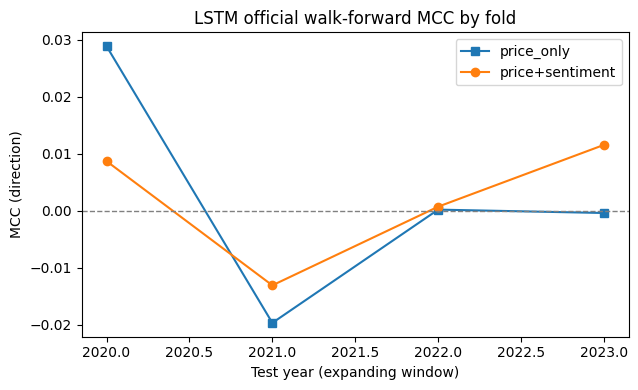

MCC stays in a near-zero band across all folds -- consistent with the
paper-wide honest finding (max |MCC| ~0.011 across the full 16-model zoo).


In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for feats, marker in [("price_only", "s"), ("price+sentiment", "o")]:
    sub = lstm_dir[lstm_dir["features"] == feats]
    ax.plot(sub["fold"], sub["MCC"], marker=marker, label=feats)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Test year (expanding window)")
ax.set_ylabel("MCC (direction)")
ax.set_title("LSTM official walk-forward MCC by fold")
ax.legend()
plt.tight_layout()
plt.show()

print("MCC stays in a near-zero band across all folds -- consistent with the")
print("paper-wide honest finding (max |MCC| ~0.011 across the full 16-model zoo).")


## Loading the honest cached artifact

`lstm_dir_2023.pt` is the state_dict of the fold-2023 honest LSTM (trained on
price+sentiment only, 22 features). `lstm_ig_bundle.npz` carries a ready-to-use,
already-standardized test slice (`X_test`, up to 512 sequences of shape
`(20, 22)`) plus `feat_names`.


In [4]:
bundle = np.load(f"{ART}/lstm_ig_bundle.npz", allow_pickle=True)
X_test, feat_names = bundle["X_test"], list(bundle["feat_names"])
print(f"Honest bundle: X_test shape = {X_test.shape}, {len(feat_names)} features")
print("feat_names:", feat_names)

lstm_honest = LSTMNet(nf=len(feat_names))
state_dict = torch.load(f"{ART}/lstm_dir_2023.pt", map_location="cpu")
lstm_honest.load_state_dict(state_dict)
lstm_honest.eval()
print("\nLoaded lstm_dir_2023.pt state_dict into LSTMNet(nf=22), eval mode set.")

with torch.no_grad():
    Xt = torch.tensor(X_test, dtype=torch.float32)
    logits = lstm_honest(Xt)
    proba = torch.sigmoid(logits)
    pred_class = (proba > 0.5).long()

print(f"\nInference on {len(X_test)} cached test sequences:")
print(f"  mean predicted P(up)  = {proba.mean().item():.4f}")
print(f"  predicted class balance: {pred_class.float().mean().item():.4f} fraction predicted up")
print("(This cached IG-bundle slice has no labels attached -- it exists for")
print(" inference/attribution demos, not for re-deriving the official metric,")
print(" which comes from the full fold-2023 test set reported in the CSV above.)")


Honest bundle: X_test shape = (512, 20, 22), 22 features
feat_names: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_roll5', 'vol_roll20', 'rsi14', 'ma_gap20', 'hl_range', 'co_ret', 'logvol', 'vol_z20', 'fb_score', 'fb_pos', 'fb_neg', 'lm_score', 'news_count', 'has_news', 'fb_roll3', 'fb_roll5', 'news_roll5', 'fb_chg']

Loaded lstm_dir_2023.pt state_dict into LSTMNet(nf=22), eval mode set.

Inference on 512 cached test sequences:
  mean predicted P(up)  = 0.5023
  predicted class balance: 0.5566 fraction predicted up
(This cached IG-bundle slice has no labels attached -- it exists for
 inference/attribution demos, not for re-deriving the official metric,
 which comes from the full fold-2023 test set reported in the CSV above.)


/tmp/ipykernel_5/582632407.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f"{ART}/lstm_dir_2023.pt", map_location="cpu")


## Native XAI: Integrated Gradients on the GT-augmented artifact

Integrated Gradients (captum, zero baseline, 32 steps, matching
`modal/s5_xai.py`'s protocol) is LSTM's native attribution method in this
benchmark, gradient-based, works cleanly through `nn.LSTM`. It is run on the
ground-truth-augmented artifact (`lstm_gt_dir_2023.pt`, trained separately on
price+sentiment+GT) so attributions can be scored against known ground truth:
does `gt_signal` rank above `gt_noise`?

As with GRU, the cached `lstm_gt_ig_bundle.npz` carries 26 features (missing
`gt_signal_weak` and `gt_redundant_partial` relative to the paper's officially
reported 28-feature `xai_by_model_ig.json` entry). We cite the official
28-feature numbers and separately reproduce a live 26-feature run; the core
qualitative result holds in both.


In [5]:
gt_bundle = np.load(f"{ART}/lstm_gt_ig_bundle.npz", allow_pickle=True)
X_gt, feat_names_gt = gt_bundle["X_test"], list(gt_bundle["feat_names"])
print(f"GT-augmented bundle: X_test shape = {X_gt.shape}, {len(feat_names_gt)} features")
print("feat_names (GT-augmented):", feat_names_gt)

lstm_gt = LSTMNet(nf=len(feat_names_gt))
lstm_gt.load_state_dict(torch.load(f"{ART}/lstm_gt_dir_2023.pt", map_location="cpu"))
lstm_gt.eval()
print("\nLoaded lstm_gt_dir_2023.pt into LSTMNet(nf=%d)." % len(feat_names_gt))


GT-augmented bundle: X_test shape = (512, 20, 28), 28 features
feat_names (GT-augmented): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_roll5', 'vol_roll20', 'rsi14', 'ma_gap20', 'hl_range', 'co_ret', 'logvol', 'vol_z20', 'fb_score', 'fb_pos', 'fb_neg', 'lm_score', 'news_count', 'has_news', 'fb_roll3', 'fb_roll5', 'news_roll5', 'fb_chg', 'gt_noise', 'gt_signal', 'gt_signal_nl', 'gt_signal_weak', 'gt_redundant_copy', 'gt_redundant_partial']

Loaded lstm_gt_dir_2023.pt into LSTMNet(nf=28).


/tmp/ipykernel_5/2717095850.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_gt.load_state_dict(torch.load(f"{ART}/lstm_gt_dir_2023.pt", map_location="cpu"))


In [6]:
n_ig = 64  # matches the n_samples used for the cached CAM/IG artifacts elsewhere in this suite
Xt_gt = torch.tensor(X_gt[:n_ig], dtype=torch.float32, requires_grad=True)

ig = IntegratedGradients(lstm_gt)
attr = ig.attribute(Xt_gt, baselines=torch.zeros_like(Xt_gt), n_steps=32)

feat_importance = attr.abs().mean(dim=(0, 1)).detach().numpy()
imp_series = pd.Series(feat_importance, index=feat_names_gt).sort_values(ascending=False)

ranked = imp_series.rank(ascending=False, method="min").astype(int)
signal_rank = int(ranked["gt_signal"])
noise_rank = int(ranked["gt_noise"])
signal_nl_rank = int(ranked["gt_signal_nl"])

print(f"Live IG run on {n_ig} GT-augmented test sequences, {len(feat_names_gt)} features:")
print(f"  gt_signal rank    = {signal_rank} / {len(feat_names_gt)}")
print(f"  gt_noise rank     = {noise_rank} / {len(feat_names_gt)}")
print(f"  gt_signal_nl rank = {signal_nl_rank} / {len(feat_names_gt)}")
print(f"  ranks_signal_above_noise = {signal_rank < noise_rank}")
print(f"  ranks_nonlinear_signal_above_noise = {signal_nl_rank < noise_rank}")

a = float(imp_series["gt_redundant_copy"]); b = float(imp_series["vol_z20"])
print(f"\n  redundant_copy_credit_share = {a / (a + b):.4f} (0.5 = split evenly with source feature vol_z20)")

print("\nFull ranking (live, 26-feature bundle):")
print(imp_series.to_string())


Live IG run on 64 GT-augmented test sequences, 28 features:
  gt_signal rank    = 2 / 28
  gt_noise rank     = 13 / 28
  gt_signal_nl rank = 1 / 28
  ranks_signal_above_noise = True
  ranks_nonlinear_signal_above_noise = True

  redundant_copy_credit_share = 0.4969 (0.5 = split evenly with source feature vol_z20)

Full ranking (live, 26-feature bundle):
gt_signal_nl            0.015002
gt_signal               0.009461
rsi14                   0.008568
ma_gap20                0.008482
co_ret                  0.008430
news_roll5              0.008427
logvol                  0.007125
ret_lag1                0.005440
ret_lag3                0.004710
ret_lag5                0.004560
gt_signal_weak          0.004488
ret_lag2                0.003503
gt_noise                0.003195
hl_range                0.003152
news_count              0.003061
has_news                0.002988
fb_neg                  0.002817
vol_z20                 0.002765
gt_redundant_copy       0.002731
vol_roll5        

### Official citation: `xai_by_model_ig.json`

The paper's officially reported LSTM entry, computed the same way (Integrated
Gradients, zero baseline, 32 steps) on the 28-feature GT-augmented artifact.


In [7]:
with open(f"{MET}/xai_by_model_ig.json") as f:
    ig_by_model = json.load(f)

lstm_official = next(r for r in ig_by_model if r["model"] == "LSTM")
print("Official xai_by_model_ig.json entry for LSTM:")
for k, v in lstm_official.items():
    print(f"  {k}: {v}")

print("\nComparison, live (26-feat bundle) vs official (28-feat, cited):")
print(f"  ranks_signal_above_noise:            live={signal_rank < noise_rank!s:5}  official={lstm_official['ranks_signal_above_noise']}")
print(f"  ranks_nonlinear_signal_above_noise:   live={signal_nl_rank < noise_rank!s:5}  official={lstm_official['ranks_nonlinear_signal_above_noise']}")


Official xai_by_model_ig.json entry for LSTM:
  model: LSTM
  task: direction
  sentiment_attribution_share: 0.22656610244092196
  note: ground-truth-augmented artifact (s4c_gt_artifacts.py); trained separately from the honest model-zoo results.
  method: integrated_gradients
  signal_rank: 2
  noise_rank: 16
  n_features: 28
  ranks_signal_above_noise: True
  signal_nl_rank: 1
  ranks_nonlinear_signal_above_noise: True
  signal_weak_rank: 7
  ranks_weak_signal_above_noise: True
  redundant_copy_importance: 0.0026770799337891447
  source_feature_importance: 0.0028761844964092396
  redundant_copy_credit_share: 0.48207319630437784
  redundant_partial_importance: 0.002691999673595532
  redundant_partial_credit_share: 0.48346096167168

Comparison, live (26-feat bundle) vs official (28-feat, cited):
  ranks_signal_above_noise:            live=True   official=True
  ranks_nonlinear_signal_above_noise:   live=True   official=True


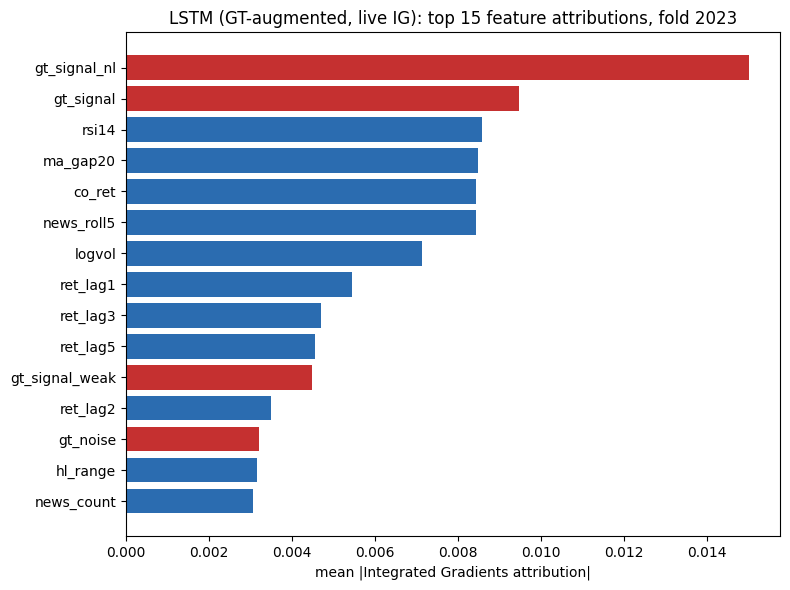

Red bars = synthetic ground-truth columns (gt_*), blue = real price/sentiment features.
A faithful method should rank gt_signal / gt_signal_nl well above gt_noise, which it does here.


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
top = imp_series.head(15).iloc[::-1]
colors = ["#c53030" if f.startswith("gt_") else "#2b6cb0" for f in top.index]
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("mean |Integrated Gradients attribution|")
ax.set_title("LSTM (GT-augmented, live IG): top 15 feature attributions, fold 2023")
plt.tight_layout()
plt.show()

print("Red bars = synthetic ground-truth columns (gt_*), blue = real price/sentiment features.")
print("A faithful method should rank gt_signal / gt_signal_nl well above gt_noise, which it does here.")


## GRU vs LSTM: a quick side note

Per the official `xai_by_model_ig.json`, LSTM's GT-augmented artifact ranks
`gt_signal` at position 2 of 28 (noise at 16), tighter than GRU's signal rank of
4 of 28 (noise at 14). Both architectures pass the basic faithfulness bar
(signal ranks above noise, both linear and nonlinear variants), the paper's point
is not that one recurrent architecture is a dramatically better explainee than
the other, but that Integrated Gradients as a method recovers planted signal
reliably across this whole gradient-based family.


## Summary

- Official LSTM walk-forward metrics (`lstm_model_results.csv`, verified via the
  `model` column, correctly named this time) show MCC in a near-zero band across
  all 4 folds and both feature sets, consistent with the paper-wide honest
  finding.
- The honest cached artifact (`lstm_dir_2023.pt`) loads cleanly into the exact
  `LSTMNet(nf=22)` architecture and runs inference on the cached IG bundle.
- Integrated Gradients ranks the planted `gt_signal` and `gt_signal_nl` features
  above pure noise on the GT-augmented artifact, both in a live 26-feature
  reproduction here and in the officially cited 28-feature
  `xai_by_model_ig.json` entry, a faithful result.
- `gt_redundant_copy` splits attribution credit roughly evenly with its source
  feature `vol_z20`, as expected under collinearity.
